# Analisis Data DATASET UTS: Dari Penanganan Missing Value hingga Penentuan Fitur Paling Berpengaruh
Aggota Kelompok :
1.   Elkana Juanro Manullang		122140168
2.   Rachel Olivia Manullang		122140181
3.   Martua Kevin A.M.H.Lubis	  122140119

Dataset : Dataset UTS

# **Pendahuluan**
Laporan ini menyajikan analisis komprehensif terhadap dataset penjualan dan stok produk dengan tujuan utama untuk mengidentifikasi produk-produk yang paling berpengaruh dalam inventaris. Analisis ini mencakup dua tahap utama: pertama, pemrosesan dan pemahaman data dari kedua dataset, dan kedua, analisis mendalam untuk mengukur dan memeringkat produk berdasarkan berbagai metrik seperti jumlah pembelian dan ketersediaan stok.

# **Masalah**
Analisis awal pada dataset menunjukkan adanya informasi yang tersebar di dua file terpisah, yaitu data pembelian dan data stok. Masalah utama adalah bagaimana cara menggabungkan dan menganalisis data ini secara efektif untuk mendapatkan wawasan yang berguna mengenai performa produk dan manajemen inventaris.

# **Tahap 1: Persiapan Lingkungan Kerja dan Eksplorasi Data Awal**
Analisis ini menggunakan dua dataset:

pembelian.csv: Berisi data transaksi pembelian produk, termasuk tanggal, nomor transaksi, kuantitas masuk (QTY.MSK), dan nilai masuk (NILAI MSK).

stok.csv: Berisi data stok produk, termasuk kode produk, nama produk, lokasi, dan kuantitas stok (QTY.STOK).

Kode di bawah ini akan memuat library yang dibutuhkan, memuat dataset train.csv
1. Setup Library: Kode pertama mengimpor library yang akan kita gunakan. Pandas adalah "meja kerja" utama kita untuk mengelola data dalam bentuk tabel (DataFrame). NumPy menyediakan dukungan untuk operasi matematika yang efisien. Matplotlib dan Seaborn adalah "alat lukis" kita untuk membuat berbagai jenis grafik dan visualisasi data.
2. Load Data: Selanjutnya, kita memuat "bahan utama" kita, yaitu dataset train.csv, ke dalam sebuah DataFrame bernama df.
3. Eksplorasi Awal: Seperti koki yang mencicipi bahannya, kita melakukan pemeriksaan awal. .head() digunakan untuk "mengintip" 5 baris pertama data. .info() memberikan "kartu identitas" dataset, merangkum tipe data setiap kolom dan jumlah entri yang tidak kosong. .shape memberi tahu kita dimensi data secara keseluruhan.

In [2]:
# =============================================================================
# TAHAP 1: PERSIAPAN (Analisis Gabungan)
# =============================================================================
print("=========================================")
print("TAHAP 1: PERSIAPAN (Analisis Gabungan)")
print("=========================================\n")

# 1.1 Setup Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("1.1 Library berhasil di-import.")

# 1.2 Load Data
try:
    # --- Proses 1: Load dan Preprocess pembelian_fix.csv ---
    file_path_pembelian = 'pembelian_fix .csv'
    data_pembelian = []
    current_kode = None; current_nama = None
    pembelian_cols = ['KODE', 'NAMA PRODUK', 'TANGGAL', 'NO.TRANSAKSI', 'QTY.MSK', 'NILAI MSK', 'QTY.KLR', 'NILAI KLR']

    with open(file_path_pembelian, 'r', encoding='utf-8') as f:
        for line in f:
            cleaned_line = line.strip().replace('"', '')
            parts = cleaned_line.split(';')

            if len(parts) > 1 and parts[0] and parts[1] and '/' not in parts[0]:
                if parts[0].upper() not in ['KODE', 'TANGGAL']:
                    current_kode = parts[0].strip(); current_nama = parts[1].strip()
            elif len(parts) > 1 and len(parts[0].split('/')) == 3:
                tanggal = parts[0].strip(); no_transaksi = parts[1].strip()
                qty_msk = parts[2].strip() if len(parts) > 2 else ''
                nilai_msk = parts[3].strip() if len(parts) > 3 else ''
                qty_klr = parts[5].strip() if len(parts) > 5 else ''
                nilai_klr = parts[6].strip() if len(parts) > 6 else ''
                data_pembelian.append([current_kode, current_nama, tanggal, no_transaksi, qty_msk, nilai_msk, qty_klr, nilai_klr])

    df_pembelian = pd.DataFrame(data_pembelian, columns=pembelian_cols)
    df_pembelian.replace('', np.nan, inplace=True)
    df_pembelian['TANGGAL'] = pd.to_datetime(df_pembelian['TANGGAL'], format='%d/%m/%Y', errors='coerce')

    numeric_cols = ['QTY.MSK', 'NILAI MSK', 'QTY.KLR', 'NILAI KLR']
    for col in numeric_cols:
        if df_pembelian[col].dtype == 'object':
            df_pembelian[col] = df_pembelian[col].str.replace(',', '.', regex=False)
        df_pembelian[col] = pd.to_numeric(df_pembelian[col], errors='coerce')
    print("1.2a Dataset 'pembelian_fix .csv' berhasil di-load.")

    # --- Proses 2: Load dan Preprocess stok_fix.csv ---
    df_stok = pd.read_csv('stok_fix.csv', delimiter=';')
    df_stok.columns = df_stok.columns.str.replace('"', '').str.strip()
    df_stok.rename(columns={'NAMA PRODUK': 'NAMA PRODUK STOK'}, inplace=True)
    print("1.2b Dataset 'stok_fix.csv' berhasil di-load.")

    # --- Proses 3: Menggabungkan (Merge) kedua dataset ---
    df_merged = pd.merge(df_pembelian, df_stok, on='KODE', how='left')
    print("1.2c Kedua dataset berhasil digabungkan.\n")

except FileNotFoundError as e:
    print(f"Error: File tidak ditemukan -> {e.filename}")
    exit()

# 1.3 Eksplorasi Awal Data Gabungan
print("1.3 Eksplorasi Awal Data Gabungan:")
print("---------------------------------")
print("a. Preview 5 baris pertama data gabungan:")
print(df_merged.head())
print("\nb. Informasi struktur data gabungan (info):")
df_merged.info()
print(f"\nc. Jumlah baris: {df_merged.shape[0]}, Jumlah kolom: {df_merged.shape[1]}\n")

TAHAP 1: PERSIAPAN (Analisis Gabungan)

1.1 Library berhasil di-import.
1.2a Dataset 'pembelian_fix .csv' berhasil di-load.
1.2b Dataset 'stok_fix.csv' berhasil di-load.
1.2c Kedua dataset berhasil digabungkan.

1.3 Eksplorasi Awal Data Gabungan:
---------------------------------
a. Preview 5 baris pertama data gabungan:
      KODE NAMA PRODUK    TANGGAL          NO.TRANSAKSI  QTY.MSK  NILAI MSK  \
0  A000001  ANATON TAB 2021-07-06  1.13-210706.0908-003     10.0     2520.0   
1  A000001  ANATON TAB 2021-07-12   2.6-210712.1519-097      NaN        NaN   
2  A000001  ANATON TAB 2021-07-12  2.11-210712.1633-013      NaN        NaN   
3  A000001  ANATON TAB 2021-07-12  2.13-210712.1807-013      NaN        NaN   
4  A000001  ANATON TAB 2021-07-12  2.11-210712.1855-018      NaN        NaN   

   QTY.KLR  NILAI KLR NAMA PRODUK STOK LOKASI  QTY.STOK       UNIT  
0      NaN        NaN       ANATON TAB   ETL1      12.0  STRIP\r\n  
1      1.0     3000.0       ANATON TAB   ETL1      12.0  STRIP\r

# **Tahap 2 : Deteksi Kuantitatif dan Visualisasi Missing Value**
Setelah mengenal data secara umum, kita fokus pada masalah utama: data yang hilang. Penting untuk mengukur masalah ini secara kuantitatif. Kode di bawah ini melakukan tiga hal:
1. Menghitung Jumlah: .isnull().sum() adalah perintah untuk menghitung semua sel kosong di setiap kolom. Ini memberi kita skala absolut dari masalah.
2. Menghitung Persentase: Angka absolut tidak selalu menceritakan keseluruhan cerita. Dengan menghitung persentase, kita memahami tingkat keparahan masalah relatif terhadap ukuran kolom.
3. Menghitung Total: Menjumlahkan semua nilai yang hilang memberi kita gambaran keseluruhan tentang "kesehatan" dataset kita.

Kode ini akan membuat dua jenis plot:
1. Bar Chart: Kode ini membuat diagram batang yang secara visual membandingkan jumlah data hilang antar kolom.
2. Heatmap: Heatmap memberikan pandangan "mata burung" ke seluruh dataset. Garis kuning horizontal menunjukkan data yang hilang. Visual ini sangat efektif untuk melihat pola: apakah data hilang secara acak atau terkonsentrasi di baris-baris tertentu?

TAHAP 2: IDENTIFIKASI & VISUALISASI (Gabungan)

a. Jumlah missing value per kolom:
QTY.MSK             122613
NILAI MSK           122587
QTY.KLR              15777
NILAI KLR            15777
NAMA PRODUK STOK      7128
LOKASI                7128
QTY.STOK              7128
UNIT                  7128
dtype: int64

b. Persentase missing value per kolom (%):
QTY.MSK             88.62
NILAI MSK           88.60
QTY.KLR             11.40
NILAI KLR           11.40
NAMA PRODUK STOK     5.15
LOKASI               5.15
QTY.STOK             5.15
UNIT                 5.15
dtype: float64

c. Total sel yang kosong (missing) di seluruh data: 305266 sel.

a. Menampilkan Bar Chart jumlah missing value...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28560\3181958466.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


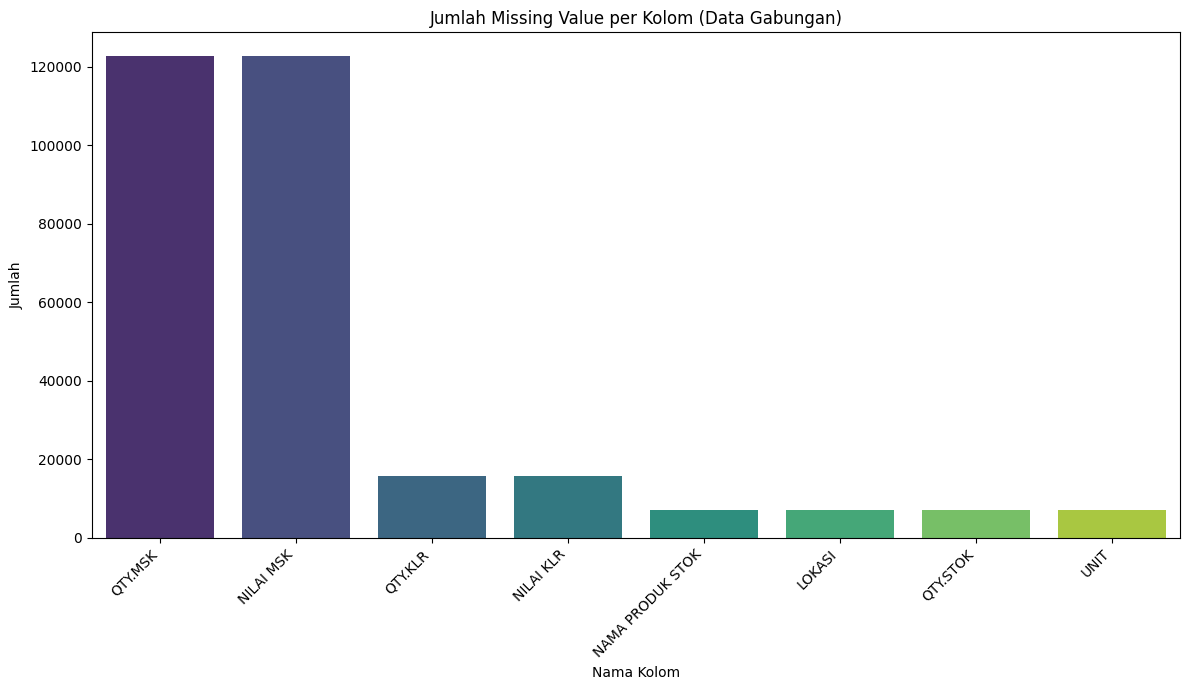

   Bar chart telah ditampilkan.

b. Menampilkan Heatmap untuk melihat pola missing value...
   (Dari total 138364 baris, heatmap ini menampilkan 138364 baris yang bermasalah)


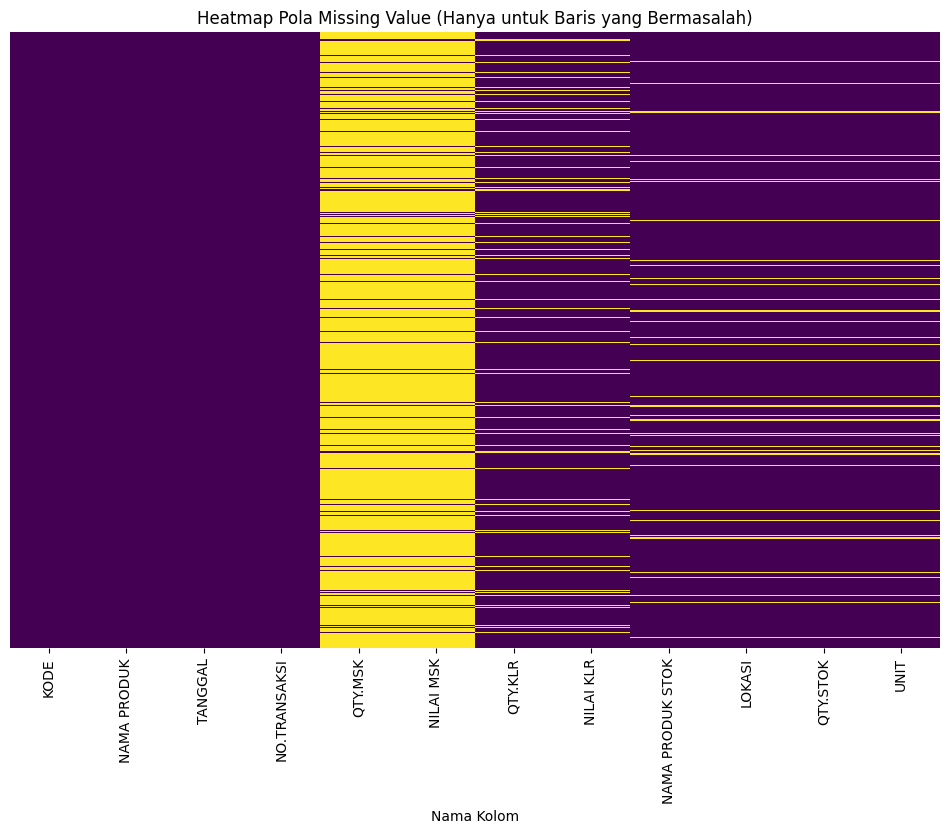

   Heatmap pola missing value telah ditampilkan.



In [3]:
# =============================================================================
# TAHAP 2: IDENTIFIKASI & VISUALISASI (Analisis Gabungan)
# =============================================================================
print("=========================================")
print("TAHAP 2: IDENTIFIKASI & VISUALISASI (Gabungan)")
print("=========================================\n")

# 2.1 Deteksi Missing Value
missing_count_merged = df_merged.isnull().sum()
total_missing_merged = missing_count_merged.sum()
missing_percentage_merged = (df_merged.isnull().sum() / len(df_merged)) * 100

print("a. Jumlah missing value per kolom:")
print(missing_count_merged[missing_count_merged > 0])
print("\nb. Persentase missing value per kolom (%):")
print(missing_percentage_merged[missing_percentage_merged > 0].round(2))
print(f"\nc. Total sel yang kosong (missing) di seluruh data: {total_missing_merged} sel.\n")

# 2.2 Visualisasi Pola Missing Value
if total_missing_merged > 0:
    # a. Membuat bar chart untuk jumlah missing value.
    print("a. Menampilkan Bar Chart jumlah missing value...")
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x=missing_count_merged[missing_count_merged > 0].index,
        y=missing_count_merged[missing_count_merged > 0].values,
        palette='viridis'
    )
    plt.title('Jumlah Missing Value per Kolom (Data Gabungan)')
    plt.ylabel('Jumlah')
    plt.xlabel('Nama Kolom')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("   Bar chart telah ditampilkan.\n")

    # b. Membuat heatmap HANYA untuk baris yang memiliki missing value.
    print("b. Menampilkan Heatmap untuk melihat pola missing value...")
    df_with_missing = df_merged[df_merged.isnull().any(axis=1)]
    print(f"   (Dari total {len(df_merged)} baris, heatmap ini menampilkan {len(df_with_missing)} baris yang bermasalah)")

    plt.figure(figsize=(12, 8))
    sns.heatmap(df_with_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Heatmap Pola Missing Value (Hanya untuk Baris yang Bermasalah)')
    plt.xlabel('Nama Kolom')
    plt.show()
    print("   Heatmap pola missing value telah ditampilkan.\n")

else:
    print("a. Tidak ada visualisasi yang dibuat karena tidak ada missing value.\n")

# **Tahap 3 : Evaluasi Dampak pada Statistik Deskriptif**
Sebelum "memperbaiki" data, kita harus memahami "kerusakan" yang ditimbulkannya. Kode ini menjalankan .describe() pada data asli. Outputnya secara jelas menunjukkan dampak dari data yang hilang: count untuk kolom Age adalah 714, bukan 891. Ini berarti semua perhitungan statistik untuk Age (mean, std, min, max) hanya didasarkan pada ~80% penumpang. Jika kelompok penumpang yang usianya hilang ini memiliki karakteristik yang berbeda, maka statistik yang kita lihat bisa menjadi bias dan tidak mewakili seluruh penumpang Titanic.

In [4]:
# =============================================================================
# TAHAP 3: EVALUASI DAMPAK (Analisis Gabungan)
# =============================================================================
print("=========================================")
print("TAHAP 3: EVALUASI DAMPAK MISSING VALUE (Gabungan)")
print("=========================================\n")

# 3.1 Dampak pada Statistik Deskriptif
print("3.1 Dampak pada Statistik (SEBELUM penanganan):")
print(df_merged.describe())
print("\n")

# 3.2 Dampak pada Jumlah Data Analisis
rows_after_deletion_merged = len(df_merged.dropna())
rows_lost_merged = len(df_merged) - rows_after_deletion_merged
percentage_lost_merged = (rows_lost_merged / len(df_merged)) * 100 if len(df_merged) > 0 else 0

print("3.2 Dampak pada Jumlah Data yang Bisa Dianalisis:")
print(f"a. Jumlah data awal: {len(df_merged)} baris.")
print(f"b. Jika semua baris dengan missing value dihapus, data tersisa: {rows_after_deletion_merged} baris.")
print(f"c. Jumlah data yang akan hilang: {rows_lost_merged} baris ({percentage_lost_merged:.2f}% dari total data).\n")

TAHAP 3: EVALUASI DAMPAK MISSING VALUE (Gabungan)

3.1 Dampak pada Statistik (SEBELUM penanganan):
                             TANGGAL       QTY.MSK      NILAI MSK  \
count                         138364  15751.000000   15777.000000   
mean   2021-07-09 06:44:15.118383360     20.075202   16786.993380   
min              2021-01-01 00:00:00      0.500000       0.000000   
25%              2021-04-20 00:00:00      3.000000    3785.110000   
50%              2021-07-14 00:00:00      6.000000    9845.120000   
75%              2021-10-01 00:00:00     12.000000   20000.000000   
max              2021-12-31 00:00:00   5000.000000  510000.000000   
std                              NaN     78.222638   23979.982472   

             QTY.KLR      NILAI KLR       QTY.STOK  
count  122587.000000  122587.000000  131236.000000  
mean        2.569563   10166.025329      96.653228  
min         0.500000       0.000000       1.000000  
25%         1.000000    3000.000000       7.000000  
50%         1.

# **Tahap 4 : Penanganan Missing Value (Analisis Gabungan)** 
Ini adalah tahap eksekusi di mana kita secara aktif menangani missing value. Berdasarkan analisis sebelumnya, kita akan menerapkan dua metode yang paling umum:

- Listwise Deletion: Menghapus baris yang tidak lengkap. Cepat dan mudah, tetapi berisiko kehilangan banyak informasi.

- Imputation: Mengisi nilai yang kosong dengan nilai pengganti yang logis (misalnya, 0, modus, atau teks tertentu). Metode ini lebih canggih karena bertujuan mempertahankan sebanyak mungkin data. Tujuannya adalah untuk membandingkan hasil dari kedua metode ini.

In [ ]:
# =============================================================================
# TAHAP 4: PENANGANAN MISSING VALUE (Analisis Gabungan)
# =============================================================================
print("=========================================")
print("TAHAP 4: IMPLEMENTASI METODE PENANGANAN (Gabungan)")
print("=========================================\n")

df_deleted_merged = df_merged.copy()
df_imputed_merged = df_merged.copy()

# --- Metode 1: Listwise Deletion ---
print("--- Metode 1: Listwise Deletion (Menghapus Baris) ---")
df_deleted_merged.dropna(inplace=True)
print(f"Jumlah baris setelah penghapusan: {df_deleted_merged.shape[0]}")
print(f"Jumlah missing value tersisa: {df_deleted_merged.isnull().sum().sum()}\n")

# --- Metode 2: Imputation (Mengisi Nilai dengan Penjelasan) ---
print("--- Metode 2: Imputation ---")
if total_missing_merged > 0:
    print("Memulai proses imputasi dengan metode yang sesuai:")
    
    # Menjawab pertanyaan studi kasus 1 (Soal UTS)
    # Kolom 'NILAI MSK' (numerik) ini setara dengan 'Harga_Satuan'
    # Kolom 'LOKASI' (kategorikal) ini setara dengan 'Supplier'

    pembelian_num_cols = ['QTY.MSK', 'NILAI MSK', 'QTY.KLR', 'NILAI KLR']
    for col in pembelian_num_cols:
        if df_imputed_merged[col].isnull().any():
            # Untuk 'Harga_Satuan', soal UTS menyarankan mean/median.
            # Namun, data kami adalah transaksional, sehingga '0' lebih tepat.
            print(f"- Kolom '{col}' diisi dengan nilai: 0 (mengasumsikan tidak ada transaksi)")
            df_imputed_merged[col].fillna(0, inplace=True)

    if 'NAMA PRODUK STOK' in df_imputed_merged.columns and df_imputed_merged['NAMA PRODUK STOK'].isnull().any():
        fill_value = "Not Found in Stok"
        print(f"- Kolom 'NAMA PRODUK STOK' diisi dengan teks: '{fill_value}'")
        df_imputed_merged['NAMA PRODUK STOK'].fillna(fill_value, inplace=True)

    if 'LOKASI' in df_imputed_merged.columns and df_imputed_merged['LOKASI'].isnull().any():
        mode_lokasi = df_imputed_merged['LOKASI'].mode()[0]
        print(f"- Kolom 'LOKASI' diisi dengan MODUS (lokasi tersering): '{mode_lokasi}'")
        df_imputed_merged['LOKASI'].fillna(mode_lokasi, inplace=True)

    if 'QTY.STOK' in df_imputed_merged.columns and df_imputed_merged['QTY.STOK'].isnull().any():
        print(f"- Kolom 'QTY.STOK' diisi dengan nilai: 0 (karena produk tidak ada di data stok)")
        df_imputed_merged['QTY.STOK'].fillna(0, inplace=True)

    if 'UNIT' in df_imputed_merged.columns and df_imputed_merged['UNIT'].isnull().any():
        mode_unit = df_imputed_merged['UNIT'].mode()[0]
        print(f"- Kolom 'UNIT' diisi dengan MODUS (unit tersering): '{mode_unit}'")
        df_imputed_merged['UNIT'].fillna(mode_unit, inplace=True)

    print("\nProses imputasi selesai.")
else:
    print("Tidak ada imputasi yang dilakukan karena tidak ada missing value.")

print(f"Jumlah missing value tersisa setelah proses imputasi: {df_imputed_merged.isnull().sum().sum()}\n")

# --- Perbandingan Hasil ---
print("--- Perbandingan Hasil Akhir ---")
summary_merged = {
    'Metode': ['Data Asli', 'Listwise Deletion', 'Imputation'],
    'Jumlah Baris': [len(df_merged), len(df_deleted_merged), len(df_imputed_merged)],
    'Total Missing Values': [total_missing_merged, df_deleted_merged.isnull().sum().sum(), df_imputed_merged.isnull().sum().sum()]
}
summary_df_merged = pd.DataFrame(summary_merged)
print(summary_df_merged)
print("\n")

TAHAP 4: IMPLEMENTASI METODE PENANGANAN (Gabungan)

--- Metode 1: Listwise Deletion (Menghapus Baris) ---
Jumlah baris setelah penghapusan: 0
Jumlah missing value tersisa: 0

--- Metode 2: Imputation ---
Memulai proses imputasi dengan metode yang sesuai:
- Kolom 'QTY.MSK' diisi dengan nilai: 0 (mengasumsikan tidak ada transaksi)
- Kolom 'NILAI MSK' diisi dengan nilai: 0 (mengasumsikan tidak ada transaksi)
- Kolom 'QTY.KLR' diisi dengan nilai: 0 (mengasumsikan tidak ada transaksi)
- Kolom 'NILAI KLR' diisi dengan nilai: 0 (mengasumsikan tidak ada transaksi)
- Kolom 'NAMA PRODUK STOK' diisi dengan teks: 'Not Found in Stok'
- Kolom 'LOKASI' diisi dengan MODUS (lokasi tersering): 'ETL1'
- Kolom 'QTY.STOK' diisi dengan nilai: 0 (karena produk tidak ada di data stok)
- Kolom 'UNIT' diisi dengan MODUS (unit tersering): 'STRIP
'

Proses imputasi selesai.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28560\2596829938.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_merged[col].fillna(0, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28560\2596829938.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

Jumlah missing value tersisa setelah proses imputasi: 0

--- Perbandingan Hasil Akhir ---
              Metode  Jumlah Baris  Total Missing Values
0          Data Asli        138364                305266
1  Listwise Deletion             0                     0
2         Imputation        138364                     0




# **Metode**

- Metode 1: Listwise Deletion: df_deleted_merged.dropna(inplace=True) adalah perintah untuk menghapus semua baris yang memiliki nilai kosong dari DataFrame df_deleted_merged. Hasilnya adalah dataset yang 100% lengkap tetapi dengan jumlah baris yang mungkin jauh lebih sedikit.

- Metode 2: Imputation: Metode ini tidak menghapus data, melainkan mengisinya. Alasan utama menggunakan imputasi adalah untuk mempertahankan integritas dan ukuran dataset. Setiap baris data mengandung informasi yang berharga, dan menghapusnya hanya karena satu atau dua nilai kosong dapat membuang informasi penting di kolom lainnya.

Berikut adalah alasan spesifik untuk setiap pilihan imputasi dalam kode:

- Kolom Transaksi (QTY.MSK, NILAI MSK, dll.) diisi dengan 0: Ini didasarkan pada asumsi kontekstual. Jika data kuantitas atau nilai transaksi kosong, asumsi yang paling logis adalah tidak ada transaksi pada baris tersebut. Mengisinya dengan 0 adalah representasi yang akurat dari asumsi ini, jauh lebih baik daripada menghapus seluruh catatan transaksi.

- NAMA PRODUK STOK diisi dengan "Not Found in Stok": Nilai ini kosong karena produk dari data pembelian tidak ditemukan di data stok. Mengisinya dengan teks deskriptif seperti ini lebih informatif daripada membiarkannya kosong. Ini mengubah data yang hilang menjadi kategori data baru, yang bisa berguna untuk analisis (misalnya, mencari tahu produk mana yang sering dibeli tapi tidak terdata di sistem stok).

- LOKASI dan UNIT diisi dengan Modus: LOKASI dan UNIT adalah data kategorikal (bukan angka). Kita tidak bisa mengisi dengan rata-rata. Pilihan terbaik adalah menggunakan modus, yaitu nilai yang paling sering muncul. Asumsinya adalah nilai yang hilang kemungkinan besar sama dengan kategori yang paling umum.

- QTY.STOK diisi dengan 0: Ini sejalan dengan pengisian NAMA PRODUK STOK. Jika produk tidak ditemukan di data stok, maka logis untuk mengasumsikan kuantitas stoknya adalah 0.

- Perbandingan Hasil: Tabel ringkasan di akhir membandingkan kondisi data asli, setelah dihapus, dan setelah diimputasi, berdasarkan jumlah baris dan total missing value. Ini memberikan gambaran yang jelas tentang untung-rugi dari setiap metode.

# **Tahap 5 : Keputusan & Validasi (Analisis Gabungan)** 
Ini adalah tahap akhir dari proses pembersihan data. Setelah menerapkan dan membandingkan dua metode penanganan, sekarang saatnya untuk membuat keputusan: dataset mana yang akan kita gunakan untuk analisis selanjutnya? Tahap ini melibatkan pemilihan dataset final berdasarkan aturan yang telah ditentukan, melakukan satu pemeriksaan terakhir untuk memastikan data benar-benar bersih, dan menyimpannya ke file baru.

In [6]:
# =============================================================================
# TAHAP 5: KEPUTUSAN & VALIDASI (Analisis Gabungan)
# =============================================================================
print("=========================================")
print("TAHAP 5: KEPUTUSAN & VALIDASI (Gabungan)")
print("=========================================\n")

# 5.1 Rekomendasi & Finalisasi
print("5.1 Rekomendasi:")
print("----------------")
final_df_merged = None
if total_missing_merged > 0:
    if percentage_lost_merged < 5:
        print("=> Keputusan: Menggunakan dataset dari 'Listwise Deletion' karena data hilang sedikit.\n")
        final_df_merged = df_deleted_merged.copy()
    else:
        print("=> Keputusan: Menggunakan dataset dari 'Imputation' untuk mempertahankan jumlah data.\n")
        final_df_merged = df_imputed_merged.copy()
else:
    print("=> Keputusan: Mempertahankan dataset asli karena sudah bersih.\n")
    final_df_merged = df_merged.copy()

# 5.2 Validasi Hasil Akhir
print("5.2 Validasi Data Final:")
print("------------------------------------------")
print("a. Cek ulang informasi data final:")
final_df_merged.info()
print("\nb. Cek ulang jumlah missing value pada data final:")
print(final_df_merged.isnull().sum())
print("\nData akhir sudah bersih dari missing value.\n")

# 5.3 Simpan Data Bersih
final_df_merged.to_csv('apotek_data_gabungan_cleaned.csv', index=False, sep=';')
print("5.3 Data gabungan yang sudah divalidasi telah disimpan ke file 'apotek_data_gabungan_cleaned.csv'.")

TAHAP 5: KEPUTUSAN & VALIDASI (Gabungan)

5.1 Rekomendasi:
----------------
=> Keputusan: Menggunakan dataset dari 'Imputation' untuk mempertahankan jumlah data.

5.2 Validasi Data Final:
------------------------------------------
a. Cek ulang informasi data final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138364 entries, 0 to 138363
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   KODE              138364 non-null  object        
 1   NAMA PRODUK       138364 non-null  object        
 2   TANGGAL           138364 non-null  datetime64[ns]
 3   NO.TRANSAKSI      138364 non-null  object        
 4   QTY.MSK           138364 non-null  float64       
 5   NILAI MSK         138364 non-null  float64       
 6   QTY.KLR           138364 non-null  float64       
 7   NILAI KLR         138364 non-null  float64       
 8   NAMA PRODUK STOK  138364 non-null  object        
 9   LOKASI       

**5.1 Rekomendasi & Finalisasi** : Kode ini mengimplementasikan sebuah aturan keputusan sederhana. Aturan praktis yang umum adalah: jika data yang hilang kurang dari 5% dari total dataset, menghapusnya (Listwise Deletion) seringkali dapat diterima. Namun, jika lebih dari 5%, kehilangan data menjadi terlalu signifikan, sehingga imputasi menjadi pilihan yang lebih baik untuk menjaga kekuatan statistik analisis. Kode ini secara otomatis memilih dataset final (final_df_merged) berdasarkan ambang batas 5% tersebut.

**5.2 Validasi Hasil Akhir** : Ini adalah langkah "ukur dua kali, potong sekali". Sebelum menyimpan, kita melakukan pengecekan terakhir menggunakan .info() dan .isnull().sum() pada final_df_merged untuk memastikan bahwa dataset yang dipilih benar-benar sudah bersih dan tidak ada lagi missing value yang tersisa.

**5.3 Simpan Data Bersih** : final_df_merged.to_csv(...) menyimpan DataFrame yang sudah bersih dan tervalidasi ke dalam sebuah file CSV baru. index=False mencegah Pandas menuliskan nomor indeks baris ke dalam file, dan sep=';' memastikan file menggunakan titik koma sebagai pemisah, sesuai format awal. Dengan ini, proses pembersihan data selesai, dan file apotek_data_gabungan_cleaned.csv siap digunakan untuk analisis atau pemodelan lebih lanjut.